Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
Path to dataset files: /kaggle/input/malicious-urls-dataset
['malicious_phish.csv']
Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
Path to dataset files: /kaggle/input/malicious-urls-dataset
['malicious_phish.csv']

--- Loading Dataset ---
Original Dataset Shape: (651191, 2)
Class Distribution:
 type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

--- Downsampling for Balanced Optimization ---
Downsampled Dataset Shape: (100000, 2)

--- Running Feature Extraction ---

--- Initializing Random Forest Classifier ---
Model training complete.

--- Evaluating Model Metrics ---
Overall Test Accuracy: 91.05%

Detailed Classification Report:
              precision    recall  f1-score   support

      benign       0.89      0.90      0.90      5000
  defacement       0.93      0.98      0.95      5000
    phishing       0.85   

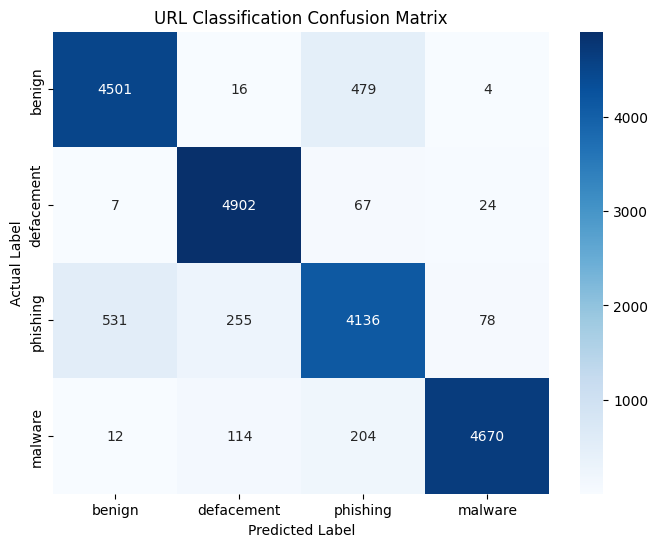

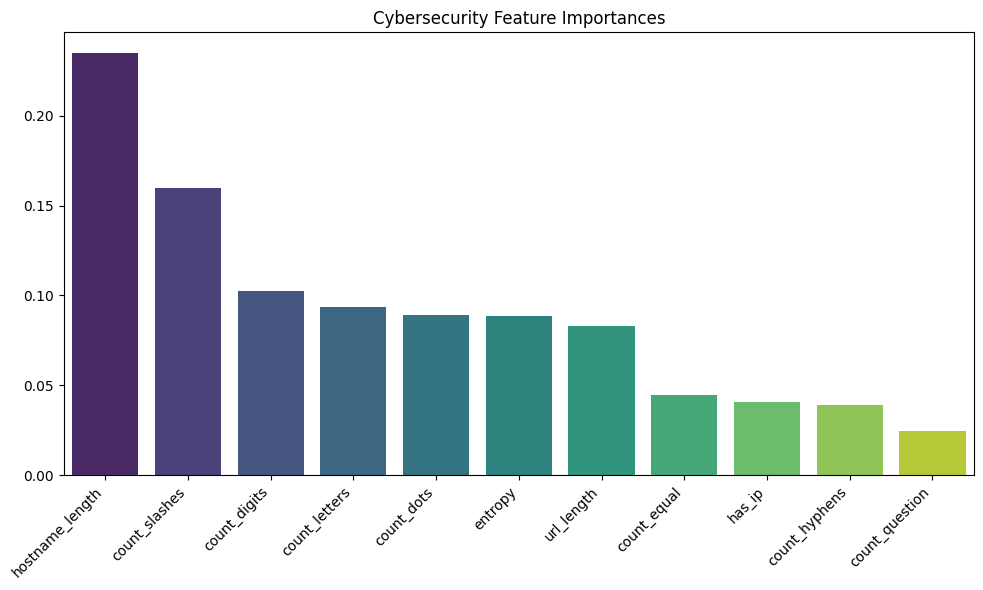

Connected to SQLite Database Successfully!
Tables Created Successfully!
Sample Records Inserted Successfully!

Database Saved Successfully!

TOTAL RECORDS IN EACH TABLE
Students          : 5
Librarians        : 5
Authors           : 5
Categories        : 5
Books             : 5
Borrow_Records    : 5

STUDENTS TABLE
(101, 'Arun Kumar', 'Computer Science', 2, 'arun@college.edu')
(102, 'Priya Sharma', 'Information Technology', 3, 'priya@college.edu')
(103, 'Rahul Verma', 'Mechanical', 1, 'rahul@college.edu')
(104, 'Sneha Iyer', 'Electronics', 4, 'sneha@college.edu')
(105, 'Vikram Singh', 'Civil', 2, 'vikram@college.edu')

BOOKS TABLE
(1001, 'Clean Code', 3, 1, '9780132350884', 10)
(1002, 'Harry Potter', 2, 2, '9780747532743', 15)
(1003, 'Five Point Someone', 1, 2, '9788129135492', 12)
(1004, 'The Da Vinci Code', 4, 2, '9780307474278', 8)
(1005, 'Malgudi Days', 5, 2, '9788185986137', 7)

BORROW RECORDS
(1, 101, 1001, 1, '2026-06-01', '2026-06-15', 'Returned')
(2, 102, 1002, 2, '2026-06-03'

Connected to library.db

DATABASE STRUCTURE TESTS
DATA QUALITY TESTS
BUSINESS LOGIC TESTS

Part 1 completed successfully.
Continue with Part 2 to execute:
- Remaining Business Logic Tests
- Edge Case Tests
- PASS/FAIL Report
- Final Summary


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "sid321axn/malicious-urls-dataset"
)

print("Path to dataset files:", path)

import os
print(os.listdir(path))

import math
import re
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.utils import resample

np.random.seed(42)
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "sid321axn/malicious-urls-dataset"
)

print("Path to dataset files:", path)

import os
print(os.listdir(path))

import math
import re
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.utils import resample

np.random.seed(42)

print("\n--- Loading Dataset ---")

df = pd.read_csv(
    os.path.join(path, "malicious_phish.csv")
)

print(f"Original Dataset Shape: {df.shape}")
print("Class Distribution:\n", df["type"].value_counts())

print("\n--- Downsampling for Balanced Optimization ---")

df_sampled = pd.DataFrame()

for category in df["type"].unique():

    df_cat = df[df["type"] == category]

    df_cat_sampled = resample(
        df_cat,
        replace=False,
        n_samples=25000,
        random_state=42
    ) if len(df_cat) > 25000 else df_cat

    df_sampled = pd.concat(
        [df_sampled, df_cat_sampled]
    )

df = df_sampled.reset_index(drop=True)

print(f"Downsampled Dataset Shape: {df.shape}")

print("\n--- Running Feature Extraction ---")


def calculate_entropy(url):
    """
    Calculates Shannon Entropy to identify
    algorithmic randomness (DGA)
    """

    url_str = str(url)

    if not url_str:
        return 0

    probabilities = [
        float(url_str.count(c)) / len(url_str)
        for c in dict.fromkeys(list(url_str))
    ]

    entropy = -sum(
        [p * math.log(p, 2) for p in probabilities]
    )

    return entropy


df["url_length"] = (
    df["url"].apply(lambda i: len(str(i)))
)

df["hostname_length"] = (
    df["url"].apply(
        lambda i:
        len(
            re.findall(
                r"https?://([^/]+)",
                str(i)
            )[0]
        )
        if re.findall(
            r"https?://([^/]+)",
            str(i)
        )
        else 0
    )
)

df["count_dots"] = (
    df["url"].apply(
        lambda i: str(i).count(".")
    )
)

df["count_hyphens"] = (
    df["url"].apply(
        lambda i: str(i).count("-")
    )
)

df["count_slashes"] = (
    df["url"].apply(
        lambda i: str(i).count("/")
    )
)

df["count_question"] = (
    df["url"].apply(
        lambda i: str(i).count("?")
    )
)

df["count_equal"] = (
    df["url"].apply(
        lambda i: str(i).count("=")
    )
)

df["count_digits"] = (
    df["url"].apply(
        lambda i:
        sum(c.isdigit() for c in str(i))
    )
)

df["count_letters"] = (
    df["url"].apply(
        lambda i:
        sum(c.isalpha() for c in str(i))
    )
)

df["has_ip"] = (
    df["url"].apply(
        lambda i: 1 if re.search(
            r'(([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.){3}'
            r'([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])',
            str(i)
        ) else 0
    )
)

df["entropy"] = (
    df["url"].apply(calculate_entropy)
)

target_mapping = {
    "benign": 0,
    "defacement": 1,
    "phishing": 2,
    "malware": 3
}

df["label"] = df["type"].map(target_mapping)

features = [
    "url_length",
    "hostname_length",
    "count_dots",
    "count_hyphens",
    "count_slashes",
    "count_question",
    "count_equal",
    "count_digits",
    "count_letters",
    "has_ip",
    "entropy"
]

X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n--- Initializing Random Forest Classifier ---")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training complete.")

print("\n--- Evaluating Model Metrics ---")

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Overall Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print("\nDetailed Classification Report:")

target_names = [
    "benign",
    "defacement",
    "phishing",
    "malware"
]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title(
    "URL Classification Confusion Matrix"
)

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")

plt.show()

# Feature Importance

importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

feature_names_sorted = [
    features[i] for i in indices
]

plt.figure(figsize=(10, 6))

plt.title(
    "Cybersecurity Feature Importances"
)

sns.barplot(
    x=feature_names_sorted,
    y=importances[indices],
    palette="viridis",
    hue=feature_names_sorted,
    legend=False
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()
# ============================================================
# College Library Management System using SQLite
# Google Colab Compatible
# ============================================================

# -----------------------------
# Import Required Libraries
# -----------------------------
import sqlite3

# -----------------------------
# Create / Connect to Database
# -----------------------------
conn = sqlite3.connect("library.db")
cursor = conn.cursor()

# Enable Foreign Key Constraints
cursor.execute("PRAGMA foreign_keys = ON")

print("Connected to SQLite Database Successfully!")

# ============================================================
# DROP TABLES (To avoid duplicate data when re-running)
# ============================================================

cursor.execute("DROP TABLE IF EXISTS Borrow_Records")
cursor.execute("DROP TABLE IF EXISTS Books")
cursor.execute("DROP TABLE IF EXISTS Students")
cursor.execute("DROP TABLE IF EXISTS Librarians")
cursor.execute("DROP TABLE IF EXISTS Authors")
cursor.execute("DROP TABLE IF EXISTS Categories")

# ============================================================
# CREATE TABLES
# ============================================================

# -----------------------------
# Students Table
# -----------------------------
cursor.execute("""
CREATE TABLE Students(
    Student_ID INTEGER PRIMARY KEY,
    Name TEXT NOT NULL,
    Department TEXT,
    Year INTEGER,
    Email TEXT UNIQUE
)
""")

# -----------------------------
# Librarians Table
# -----------------------------
cursor.execute("""
CREATE TABLE Librarians(
    Librarian_ID INTEGER PRIMARY KEY,
    Name TEXT NOT NULL,
    Phone TEXT,
    Email TEXT UNIQUE
)
""")

# -----------------------------
# Authors Table
# -----------------------------
cursor.execute("""
CREATE TABLE Authors(
    Author_ID INTEGER PRIMARY KEY,
    Author_Name TEXT NOT NULL,
    Country TEXT
)
""")

# -----------------------------
# Categories Table
# -----------------------------
cursor.execute("""
CREATE TABLE Categories(
    Category_ID INTEGER PRIMARY KEY,
    Category_Name TEXT NOT NULL
)
""")

# -----------------------------
# Books Table
# -----------------------------
cursor.execute("""
CREATE TABLE Books(
    Book_ID INTEGER PRIMARY KEY,
    Title TEXT NOT NULL,
    Author_ID INTEGER,
    Category_ID INTEGER,
    ISBN TEXT UNIQUE,
    Copies INTEGER,

    FOREIGN KEY (Author_ID)
        REFERENCES Authors(Author_ID),

    FOREIGN KEY (Category_ID)
        REFERENCES Categories(Category_ID)
)
""")

# -----------------------------
# Borrow Records Table
# -----------------------------
cursor.execute("""
CREATE TABLE Borrow_Records(
    Borrow_ID INTEGER PRIMARY KEY,
    Student_ID INTEGER,
    Book_ID INTEGER,
    Librarian_ID INTEGER,
    Borrow_Date TEXT,
    Return_Date TEXT,
    Status TEXT,

    FOREIGN KEY(Student_ID)
        REFERENCES Students(Student_ID),

    FOREIGN KEY(Book_ID)
        REFERENCES Books(Book_ID),

    FOREIGN KEY(Librarian_ID)
        REFERENCES Librarians(Librarian_ID)
)
""")

print("Tables Created Successfully!")

# ============================================================
# INSERT SAMPLE DATA
# ============================================================

# -----------------------------
# Students
# -----------------------------
students = [
    (101, "Arun Kumar", "Computer Science", 2, "arun@college.edu"),
    (102, "Priya Sharma", "Information Technology", 3, "priya@college.edu"),
    (103, "Rahul Verma", "Mechanical", 1, "rahul@college.edu"),
    (104, "Sneha Iyer", "Electronics", 4, "sneha@college.edu"),
    (105, "Vikram Singh", "Civil", 2, "vikram@college.edu")
]

cursor.executemany("""
INSERT INTO Students
VALUES (?, ?, ?, ?, ?)
""", students)

# -----------------------------
# Librarians
# -----------------------------
librarians = [
    (1, "Meena", "9876543210", "meena@library.com"),
    (2, "Ravi", "9876543211", "ravi@library.com"),
    (3, "Lakshmi", "9876543212", "lakshmi@library.com"),
    (4, "Joseph", "9876543213", "joseph@library.com"),
    (5, "Anita", "9876543214", "anita@library.com")
]

cursor.executemany("""
INSERT INTO Librarians
VALUES (?, ?, ?, ?)
""", librarians)

# -----------------------------
# Authors
# -----------------------------
authors = [
    (1, "Chetan Bhagat", "India"),
    (2, "J. K. Rowling", "United Kingdom"),
    (3, "Robert C. Martin", "USA"),
    (4, "Dan Brown", "USA"),
    (5, "R. K. Narayan", "India")
]

cursor.executemany("""
INSERT INTO Authors
VALUES (?, ?, ?)
""", authors)

# -----------------------------
# Categories
# -----------------------------
categories = [
    (1, "Programming"),
    (2, "Fiction"),
    (3, "Science"),
    (4, "History"),
    (5, "Technology")
]

cursor.executemany("""
INSERT INTO Categories
VALUES (?, ?)
""", categories)

# -----------------------------
# Books
# -----------------------------
books = [
    (1001, "Clean Code", 3, 1, "9780132350884", 10),
    (1002, "Harry Potter", 2, 2, "9780747532743", 15),
    (1003, "Five Point Someone", 1, 2, "9788129135492", 12),
    (1004, "The Da Vinci Code", 4, 2, "9780307474278", 8),
    (1005, "Malgudi Days", 5, 2, "9788185986137", 7)
]

cursor.executemany("""
INSERT INTO Books
VALUES (?, ?, ?, ?, ?, ?)
""", books)

# -----------------------------
# Borrow Records
# -----------------------------
borrow_records = [
    (1, 101, 1001, 1, "2026-06-01", "2026-06-15", "Returned"),
    (2, 102, 1002, 2, "2026-06-03", "2026-06-17", "Borrowed"),
    (3, 103, 1003, 3, "2026-06-05", "2026-06-19", "Returned"),
    (4, 104, 1004, 4, "2026-06-08", "2026-06-22", "Borrowed"),
    (5, 105, 1005, 5, "2026-06-10", "2026-06-24", "Returned")
]

cursor.executemany("""
INSERT INTO Borrow_Records
VALUES (?, ?, ?, ?, ?, ?, ?)
""", borrow_records)

print("Sample Records Inserted Successfully!")

# ============================================================
# COMMIT CHANGES
# ============================================================

conn.commit()

print("\nDatabase Saved Successfully!")

# ============================================================
# DISPLAY RECORD COUNT
# ============================================================

tables = [
    "Students",
    "Librarians",
    "Authors",
    "Categories",
    "Books",
    "Borrow_Records"
]

print("\n===============================")
print("TOTAL RECORDS IN EACH TABLE")
print("===============================")

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table:18s}: {count}")

# ============================================================
# OPTIONAL - DISPLAY DATA
# ============================================================

print("\n===============================")
print("STUDENTS TABLE")
print("===============================")

cursor.execute("SELECT * FROM Students")
for row in cursor.fetchall():
    print(row)

print("\n===============================")
print("BOOKS TABLE")
print("===============================")

cursor.execute("SELECT * FROM Books")
for row in cursor.fetchall():
    print(row)

print("\n===============================")
print("BORROW RECORDS")
print("===============================")

cursor.execute("SELECT * FROM Borrow_Records")
for row in cursor.fetchall():
    print(row)

# ============================================================
# CLOSE DATABASE CONNECTION
# ============================================================

conn.close()

print("\nSQLite Connection Closed Successfully!")
# ============================================================
# College Library Management System
# Search & Retrieval Functions
# Google Colab Compatible
# (Uses the existing library.db database)
# ============================================================

import sqlite3

# ------------------------------------------------------------
# Connect to Existing SQLite Database
# ------------------------------------------------------------
conn = sqlite3.connect("library.db")
cursor = conn.cursor()

print("Connected to library.db successfully!")

# ============================================================
# 1. Search Books by Title
# ============================================================

def search_book_by_title(title):
    """
    Search books using full or partial title.
    """

    query = """
    SELECT
        B.Book_ID,
        B.Title,
        A.Author_Name,
        C.Category_Name,
        B.Copies
    FROM Books B
    JOIN Authors A
        ON B.Author_ID = A.Author_ID
    JOIN Categories C
        ON B.Category_ID = C.Category_ID
    WHERE B.Title LIKE ?
    """

    cursor.execute(query, ('%' + title + '%',))
    results = cursor.fetchall()

    print("\n========== SEARCH BY TITLE ==========")

    if results:
        for row in results:
            print(row)
    else:
        print("No books found.")


# ============================================================
# 2. Search Books by Author
# ============================================================

def search_book_by_author(author):
    """
    Search books using author name.
    """

    query = """
    SELECT
        B.Book_ID,
        B.Title,
        A.Author_Name,
        C.Category_Name,
        B.Copies
    FROM Books B
    JOIN Authors A
        ON B.Author_ID = A.Author_ID
    JOIN Categories C
        ON B.Category_ID = C.Category_ID
    WHERE A.Author_Name LIKE ?
    """

    cursor.execute(query, ('%' + author + '%',))
    results = cursor.fetchall()

    print("\n========== SEARCH BY AUTHOR ==========")

    if results:
        for row in results:
            print(row)
    else:
        print("No books found.")


# ============================================================
# 3. Filter Books by Category
# ============================================================

def filter_books_by_category(category):
    """
    Display all books in a given category.
    """

    query = """
    SELECT
        B.Book_ID,
        B.Title,
        A.Author_Name,
        C.Category_Name,
        B.Copies
    FROM Books B
    JOIN Authors A
        ON B.Author_ID = A.Author_ID
    JOIN Categories C
        ON B.Category_ID = C.Category_ID
    WHERE C.Category_Name LIKE ?
    """

    cursor.execute(query, ('%' + category + '%',))
    results = cursor.fetchall()

    print("\n========== FILTER BY CATEGORY ==========")

    if results:
        for row in results:
            print(row)
    else:
        print("No books found.")


# ============================================================
# 4. List All Available Books
# ============================================================

def list_available_books():
    """
    Display all books having copies greater than zero.
    """

    query = """
    SELECT
        B.Book_ID,
        B.Title,
        A.Author_Name,
        C.Category_Name,
        B.Copies
    FROM Books B
    JOIN Authors A
        ON B.Author_ID = A.Author_ID
    JOIN Categories C
        ON B.Category_ID = C.Category_ID
    WHERE B.Copies > 0
    ORDER BY B.Title
    """

    cursor.execute(query)
    results = cursor.fetchall()

    print("\n========== AVAILABLE BOOKS ==========")

    if results:
        for row in results:
            print(row)
    else:
        print("No available books.")


# ============================================================
# 5. Books Borrowed by a Specific Student
# ============================================================

def books_borrowed_by_student(student_id):
    """
    Display books currently borrowed by a student.
    """

    query = """
    SELECT
        S.Student_ID,
        S.Name,
        B.Title,
        BR.Borrow_Date,
        BR.Return_Date,
        BR.Status
    FROM Borrow_Records BR
    JOIN Students S
        ON BR.Student_ID = S.Student_ID
    JOIN Books B
        ON BR.Book_ID = B.Book_ID
    WHERE
        S.Student_ID = ?
        AND BR.Status='Borrowed'
    """

    cursor.execute(query, (student_id,))
    results = cursor.fetchall()

    print("\n========== BOOKS BORROWED BY STUDENT ==========")

    if results:
        for row in results:
            print(row)
    else:
        print("No borrowed books for this student.")


# ============================================================
# 6. Display All Borrowing Records
# ============================================================

def display_all_borrow_records():
    """
    Display complete borrowing history.
    """

    query = """
    SELECT
        BR.Borrow_ID,
        S.Name,
        B.Title,
        L.Name,
        BR.Borrow_Date,
        BR.Return_Date,
        BR.Status
    FROM Borrow_Records BR
    JOIN Students S
        ON BR.Student_ID = S.Student_ID
    JOIN Books B
        ON BR.Book_ID = B.Book_ID
    JOIN Librarians L
        ON BR.Librarian_ID = L.Librarian_ID
    ORDER BY BR.Borrow_ID
    """

    cursor.execute(query)
    results = cursor.fetchall()

    print("\n========== ALL BORROW RECORDS ==========")

    if results:
        for row in results:
            print(row)
    else:
        print("No records found.")


# ============================================================
# TESTING ALL FUNCTIONS
# ============================================================

print("\n")
print("===================================================")
print("TESTING SEARCH AND RETRIEVAL FUNCTIONS")
print("===================================================")

# ------------------------------------------------------------
# Test 1
# ------------------------------------------------------------
search_book_by_title("Harry")

# ------------------------------------------------------------
# Test 2
# ------------------------------------------------------------
search_book_by_author("Martin")

# ------------------------------------------------------------
# Test 3
# ------------------------------------------------------------
filter_books_by_category("Programming")

# ------------------------------------------------------------
# Test 4
# ------------------------------------------------------------
list_available_books()

# ------------------------------------------------------------
# Test 5
# ------------------------------------------------------------
books_borrowed_by_student(102)

# ------------------------------------------------------------
# Test 6
# ------------------------------------------------------------
display_all_borrow_records()

# ============================================================
# Close Connection
# ============================================================

conn.close()

print("\nDatabase connection closed successfully.")
# ============================================================
# College Library Management System
# Business Function : Borrow Book
# Google Colab Compatible
# (Uses the existing library.db database)
# ============================================================

import sqlite3
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Connect to Existing Database
# ------------------------------------------------------------
conn = sqlite3.connect("library.db")
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON")

print("Connected to library.db Successfully!\n")

# ============================================================
# Function : borrow_book()
# ============================================================

def borrow_book(student_id, book_id):
    """
    Borrow a book after validating:
    1. Student exists
    2. Book exists
    3. Copies available
    4. Duplicate borrowing not allowed
    """

    print("=" * 60)
    print(f"Borrow Request -> Student ID: {student_id} | Book ID: {book_id}")
    print("=" * 60)

    # --------------------------------------------------------
    # Step 1 : Validate Student
    # --------------------------------------------------------
    cursor.execute("""
        SELECT Name
        FROM Students
        WHERE Student_ID=?
    """, (student_id,))

    student = cursor.fetchone()

    if student is None:
        print("❌ Invalid Student ID.")
        return

    # --------------------------------------------------------
    # Step 2 : Validate Book
    # --------------------------------------------------------
    cursor.execute("""
        SELECT Title, Copies
        FROM Books
        WHERE Book_ID=?
    """, (book_id,))

    book = cursor.fetchone()

    if book is None:
        print("❌ Invalid Book ID.")
        return

    title = book[0]
    copies = book[1]

    # --------------------------------------------------------
    # Step 3 : Check Available Copies
    # --------------------------------------------------------
    if copies <= 0:
        print("❌ No copies available.")
        return

    # --------------------------------------------------------
    # Step 4 : Prevent Duplicate Borrowing
    # --------------------------------------------------------
    cursor.execute("""
        SELECT *
        FROM Borrow_Records
        WHERE Student_ID=?
        AND Book_ID=?
        AND Status='Borrowed'
    """, (student_id, book_id))

    duplicate = cursor.fetchone()

    if duplicate:
        print("❌ Student has already borrowed this book.")
        return

    # --------------------------------------------------------
    # Step 5 : Generate New Borrow ID
    # --------------------------------------------------------
    cursor.execute("""
        SELECT IFNULL(MAX(Borrow_ID),0)+1
        FROM Borrow_Records
    """)

    borrow_id = cursor.fetchone()[0]

    # --------------------------------------------------------
    # Step 6 : Borrow & Return Dates
    # --------------------------------------------------------
    borrow_date = datetime.today().strftime("%Y-%m-%d")
    return_date = (datetime.today() + timedelta(days=14)).strftime("%Y-%m-%d")

    # --------------------------------------------------------
    # Step 7 : Select Librarian
    # --------------------------------------------------------
    # Using Librarian ID = 1 for demo
    librarian_id = 1

    # --------------------------------------------------------
    # Step 8 : Insert Borrow Record
    # --------------------------------------------------------
    cursor.execute("""
        INSERT INTO Borrow_Records
        (
            Borrow_ID,
            Student_ID,
            Book_ID,
            Librarian_ID,
            Borrow_Date,
            Return_Date,
            Status
        )
        VALUES
        (?, ?, ?, ?, ?, ?, ?)
    """,
    (
        borrow_id,
        student_id,
        book_id,
        librarian_id,
        borrow_date,
        return_date,
        "Borrowed"
    ))

    # --------------------------------------------------------
    # Step 9 : Update Book Copies
    # --------------------------------------------------------
    cursor.execute("""
        UPDATE Books
        SET Copies = Copies - 1
        WHERE Book_ID=?
    """, (book_id,))

    conn.commit()

    print("✅ Book Borrowed Successfully!")
    print("Student :", student[0])
    print("Book    :", title)
    print("Borrow Date :", borrow_date)
    print("Return Date :", return_date)
    print()

# ============================================================
# TEST CASES
# ============================================================

print("\n")
print("============================================================")
print("TEST CASE 1 : SUCCESSFUL BORROW")
print("============================================================")

# Student 101 has returned book 1001 in sample data
borrow_book(101,1001)


print("\n")
print("============================================================")
print("TEST CASE 2 : INVALID STUDENT ID")
print("============================================================")

borrow_book(999,1001)


print("\n")
print("============================================================")
print("TEST CASE 3 : INVALID BOOK ID")
print("============================================================")

borrow_book(101,9999)


print("\n")
print("============================================================")
print("TEST CASE 4 : NO COPIES AVAILABLE")
print("============================================================")

# Set copies to zero temporarily
cursor.execute("""
UPDATE Books
SET Copies=0
WHERE Book_ID=1005
""")

conn.commit()

borrow_book(101,1005)

# Restore copies
cursor.execute("""
UPDATE Books
SET Copies=7
WHERE Book_ID=1005
""")

conn.commit()


print("\n")
print("============================================================")
print("TEST CASE 5 : DUPLICATE BORROWING")
print("============================================================")

# Student 102 already has Book 1002 with Status='Borrowed'
borrow_book(102,1002)


# ============================================================
# DISPLAY UPDATED BOOK TABLE
# ============================================================

print("\n")
print("============================================================")
print("UPDATED BOOK COPIES")
print("============================================================")

cursor.execute("""
SELECT Book_ID,
       Title,
       Copies
FROM Books
ORDER BY Book_ID
""")

for row in cursor.fetchall():
    print(row)


# ============================================================
# DISPLAY LATEST BORROW RECORDS
# ============================================================

print("\n")
print("============================================================")
print("LATEST BORROW RECORDS")
print("============================================================")

cursor.execute("""
SELECT Borrow_ID,
       Student_ID,
       Book_ID,
       Borrow_Date,
       Return_Date,
       Status
FROM Borrow_Records
ORDER BY Borrow_ID DESC
LIMIT 10
""")

for row in cursor.fetchall():
    print(row)


# ============================================================
# CLOSE DATABASE
# ============================================================

conn.close()

print("\nDatabase connection closed successfully.")
# ============================================================
# College Library Management System
# HTML Frontend using IPython.display.HTML
# Google Colab Compatible
# ============================================================

import sqlite3
from datetime import datetime
from IPython.display import HTML, display

# ------------------------------------------------------------
# Connect to SQLite Database
# ------------------------------------------------------------
conn = sqlite3.connect("library.db")
cursor = conn.cursor()

# ============================================================
# Retrieve Books
# ============================================================

cursor.execute("""
SELECT
    Books.Book_ID,
    Books.Title,
    Authors.Author_Name,
    Categories.Category_Name,
    Books.Copies
FROM Books
JOIN Authors
ON Books.Author_ID = Authors.Author_ID
JOIN Categories
ON Books.Category_ID = Categories.Category_ID
ORDER BY Books.Title
""")

books = cursor.fetchall()

# ============================================================
# Student Dashboard Statistics
# (Using Student ID = 101 for demo)
# ============================================================

student_id = 101

# Total Borrowed
cursor.execute("""
SELECT COUNT(*)
FROM Borrow_Records
WHERE Student_ID=?
""",(student_id,))
total_borrowed = cursor.fetchone()[0]

# Active Borrowings
cursor.execute("""
SELECT COUNT(*)
FROM Borrow_Records
WHERE Student_ID=?
AND Status='Borrowed'
""",(student_id,))
active = cursor.fetchone()[0]

# Due Books
today = datetime.today().strftime("%Y-%m-%d")

cursor.execute("""
SELECT COUNT(*)
FROM Borrow_Records
WHERE Student_ID=?
AND Status='Borrowed'
AND Return_Date <= ?
""",(student_id,today))

due = cursor.fetchone()[0]

# ============================================================
# Create Book Cards
# ============================================================

book_cards = ""

for book in books:

    status = "Available" if book[4] > 0 else "Not Available"

    color = "#28a745" if book[4] > 0 else "#dc3545"

    book_cards += f"""
    <div class="book-card">

        <h3>{book[1]}</h3>

        <p><b>Author:</b> {book[2]}</p>

        <p><b>Category:</b> {book[3]}</p>

        <p><b>Copies:</b> {book[4]}</p>

        <span class="status"
        style="background:{color};">
        {status}
        </span>

    </div>
    """

# ============================================================
# HTML Page
# ============================================================

html = f"""

<!DOCTYPE html>

<html>

<head>

<style>

*{{
margin:0;
padding:0;
box-sizing:border-box;
font-family:Arial,Helvetica,sans-serif;
}}

body{{
background:#eef4fb;
}}

header{{
background:#1565c0;
color:white;
padding:25px;
text-align:center;
font-size:34px;
font-weight:bold;
}}

nav{{
background:#0d47a1;
padding:15px;
text-align:center;
}}

nav a{{
color:white;
text-decoration:none;
margin:20px;
font-size:18px;
font-weight:bold;
}}

nav a:hover{{
color:#ffeb3b;
}}

.hero{{
padding:45px;
text-align:center;
background:white;
margin:20px;
border-radius:12px;
box-shadow:0 2px 8px rgba(0,0,0,.15);
}}

.hero h2{{
color:#1565c0;
margin-bottom:15px;
}}

.hero p{{
font-size:18px;
color:#555;
}}

.dashboard{{
display:grid;
grid-template-columns:repeat(auto-fit,minmax(220px,1fr));
gap:20px;
margin:20px;
}}

.card{{
background:white;
padding:25px;
text-align:center;
border-radius:10px;
box-shadow:0 2px 8px rgba(0,0,0,.15);
}}

.card h3{{
color:#1565c0;
margin-bottom:10px;
}}

.card h1{{
color:#0d47a1;
}}

.section-title{{
text-align:center;
font-size:32px;
margin-top:35px;
color:#1565c0;
font-weight:bold;
}}

.book-grid{{
display:grid;
grid-template-columns:repeat(auto-fit,minmax(260px,1fr));
gap:20px;
padding:30px;
}}

.book-card{{
background:white;
padding:20px;
border-radius:12px;
box-shadow:0 2px 8px rgba(0,0,0,.15);
transition:.3s;
}}

.book-card:hover{{
transform:translateY(-5px);
}}

.book-card h3{{
color:#1565c0;
margin-bottom:10px;
}}

.book-card p{{
margin:6px 0;
}}

.status{{
display:inline-block;
padding:8px 16px;
border-radius:20px;
color:white;
font-weight:bold;
margin-top:12px;
}}

footer{{
margin-top:40px;
background:#0d47a1;
color:white;
text-align:center;
padding:20px;
font-size:16px;
}}

@media(max-width:768px){{

header{{
font-size:26px;
}}

nav a{{
display:block;
margin:10px;
}}

}}

</style>

</head>

<body>

<header>

College Library Management System

</header>

<nav>

<a href="#">Home</a>

<a href="#">Books</a>

<a href="#">Students</a>

<a href="#">Borrow Records</a>

<a href="#">Contact</a>

</nav>

<section class="hero">

<h2>Welcome to the College Library</h2>

<p>

Manage books, students, librarians and borrowing records efficiently
using this Library Management System.

</p>

</section>

<h2 class="section-title">

Student Status Dashboard

</h2>

<div class="dashboard">

<div class="card">

<h3>Total Books Borrowed</h3>

<h1>{total_borrowed}</h1>

</div>

<div class="card">

<h3>Active Borrowings</h3>

<h1>{active}</h1>

</div>

<div class="card">

<h3>Due Books</h3>

<h1>{due}</h1>

</div>

</div>

<h2 class="section-title">

Available Books

</h2>

<div class="book-grid">

{book_cards}

</div>

<footer>

© 2026 College Library Management System |
Software Development using Generative AI Assignment

</footer>

</body>

</html>

"""

# ============================================================
# Display HTML
# ============================================================

display(HTML(html))

# ============================================================
# Close Database
# ============================================================

conn.close()
# ============================================================
# PHASE 5 - AUTOMATED TEST SUITE
# College Library Management System
# Google Colab Compatible
# PART 1
# ============================================================

import sqlite3
import io
from contextlib import redirect_stdout

# ------------------------------------------------------------
# Connect Database
# ------------------------------------------------------------
conn = sqlite3.connect("library.db")
cursor = conn.cursor()

print("Connected to library.db\n")

# ============================================================
# PASS / FAIL REPORT FRAMEWORK
# ============================================================

results = []

def add_result(test_name, category, expected, actual, passed):
    results.append({
        "Test Name": test_name,
        "Category": category,
        "Expected": expected,
        "Actual": actual,
        "Status": "PASS" if passed else "FAIL"
    })


# ============================================================
# DATABASE STRUCTURE TESTS
# ============================================================

print("="*60)
print("DATABASE STRUCTURE TESTS")
print("="*60)

required_tables = [
    "Students",
    "Librarians",
    "Authors",
    "Categories",
    "Books",
    "Borrow_Records"
]

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
""")

existing_tables = [row[0] for row in cursor.fetchall()]

for table in required_tables:

    passed = table in existing_tables

    add_result(
        table + " Exists",
        "Database Structure",
        "Table Exists",
        "Exists" if passed else "Missing",
        passed
    )


# ============================================================
# DATA QUALITY TESTS
# ============================================================

print("="*60)
print("DATA QUALITY TESTS")
print("="*60)

# ------------------------------------------------------------
# Student Name NOT NULL
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Students
WHERE Name IS NULL
OR TRIM(Name)=''
""")

count = cursor.fetchone()[0]

add_result(
    "Student Name",
    "Data Quality",
    "No NULL Names",
    f"{count} Invalid",
    count == 0
)

# ------------------------------------------------------------
# Librarian Name
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Librarians
WHERE Name IS NULL
OR TRIM(Name)=''
""")

count = cursor.fetchone()[0]

add_result(
    "Librarian Name",
    "Data Quality",
    "No NULL Names",
    f"{count} Invalid",
    count == 0
)

# ------------------------------------------------------------
# Author Name
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Authors
WHERE Author_Name IS NULL
OR TRIM(Author_Name)=''
""")

count = cursor.fetchone()[0]

add_result(
    "Author Name",
    "Data Quality",
    "No NULL Names",
    f"{count} Invalid",
    count == 0
)

# ------------------------------------------------------------
# Category Name
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Categories
WHERE Category_Name IS NULL
OR TRIM(Category_Name)=''
""")

count = cursor.fetchone()[0]

add_result(
    "Category Name",
    "Data Quality",
    "No NULL Names",
    f"{count} Invalid",
    count == 0
)

# ------------------------------------------------------------
# Book Title
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Books
WHERE Title IS NULL
OR TRIM(Title)=''
""")

count = cursor.fetchone()[0]

add_result(
    "Book Title",
    "Data Quality",
    "No NULL Titles",
    f"{count} Invalid",
    count == 0
)

# ------------------------------------------------------------
# Negative Copies
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Books
WHERE Copies < 0
""")

count = cursor.fetchone()[0]

add_result(
    "Negative Copies",
    "Data Quality",
    "No Negative Copies",
    f"{count} Found",
    count == 0
)

# ------------------------------------------------------------
# Duplicate ISBN
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM
(
SELECT ISBN
FROM Books
GROUP BY ISBN
HAVING COUNT(*)>1
)
""")

count = cursor.fetchone()[0]

add_result(
    "Duplicate ISBN",
    "Data Quality",
    "Unique ISBN",
    f"{count} Duplicate",
    count == 0
)

# ------------------------------------------------------------
# Duplicate Student Email
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM
(
SELECT Email
FROM Students
GROUP BY Email
HAVING COUNT(*)>1
)
""")

count = cursor.fetchone()[0]

add_result(
    "Duplicate Student Email",
    "Data Quality",
    "Unique Emails",
    f"{count} Duplicate",
    count == 0
)


# ============================================================
# BUSINESS LOGIC TESTS
# ============================================================

print("="*60)
print("BUSINESS LOGIC TESTS")
print("="*60)

# ------------------------------------------------------------
# Valid Borrow
# ------------------------------------------------------------

cursor.execute("SELECT Copies FROM Books WHERE Book_ID=1001")
before = cursor.fetchone()[0]

buffer = io.StringIO()

with redirect_stdout(buffer):
    borrow_book(101,1001)

output = buffer.getvalue()

passed = "Book Borrowed Successfully" in output

add_result(
    "Valid Borrow",
    "Business Logic",
    "Borrow Success",
    "Success" if passed else "Failed",
    passed
)

# ------------------------------------------------------------
# Copies Reduced
# ------------------------------------------------------------

cursor.execute("SELECT Copies FROM Books WHERE Book_ID=1001")
after = cursor.fetchone()[0]

passed = (before - after) == 1

add_result(
    "Copies Reduced",
    "Business Logic",
    "Decrease by 1",
    f"{before}->{after}",
    passed
)

# ------------------------------------------------------------
# Borrow Record Inserted
# ------------------------------------------------------------

cursor.execute("""
SELECT COUNT(*)
FROM Borrow_Records
WHERE Student_ID=101
AND Book_ID=1001
AND Status='Borrowed'
""")

count = cursor.fetchone()[0]

add_result(
    "Borrow Record",
    "Business Logic",
    "Record Inserted",
    f"{count} Found",
    count > 0
)

print("\nPart 1 completed successfully.")
print("Continue with Part 2 to execute:")
print("- Remaining Business Logic Tests")
print("- Edge Case Tests")
print("- PASS/FAIL Report")
print("- Final Summary")

# Keep connection open for Part 2

